# Mutual information between FP sequence and photophysical traits

This notebook quantifies **how much information a fluorescent-protein's amino-acid
sequence carries about each of its measured quantitative traits**, using a
non-parametric mutual-information (MI) estimator.

Pipeline:

1. **k-mer representation** — encode every protein sequence as a normalized
   k-mer (k=2) frequency vector, then reduce to a compact set of principal
   components (KSG degrades in very high dimensions, so we work in a low-D
   sequence embedding).
2. **KSG estimator** — implement the Kraskov–Stögbauer–Grassberger (2004)
   kNN estimator of $I(X;Y)$ from scratch (algorithm 1, max-norm joint metric),
   and validate it against the analytic MI of a bivariate Gaussian and against
   `sklearn`.
3. **MI pipeline** — estimate $I(\text{sequence};\text{trait})$ for each
   quantitative trait (`ex_max`, `em_max`, `ext_coeff`, `qy`, `brightness`,
   `pka`, `maturation`), with a label-shuffled permutation null for
   significance, and visualize all traits in a single bar plot.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import product
from scipy.spatial import cKDTree
from scipy.special import digamma
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_regression

rng = np.random.default_rng(0)
plt.rcParams["figure.dpi"] = 110

DATA = "fpbase_output/fpbase_proteins.csv"
TRAITS = ["ex_max", "em_max", "ext_coeff", "qy", "brightness", "pka", "maturation"]

df = pd.read_csv(DATA)
print("rows x cols:", df.shape)
print("rows with a sequence:", df["seq"].notna().sum())
df[["name", "seq_length"] + TRAITS].head()

rows x cols: (1177, 34)
rows with a sequence: 1115


,name,seq_length,ex_max,em_max,ext_coeff,qy,brightness,pka,maturation
0,10B,238.0,513.0,525.0,30800.0,NaN,NaN,NaN,NaN
1,11,238.0,502.0,512.0,33000.0,NaN,NaN,NaN,NaN
2,22G,224.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,(3-F)Tyr-EGFP,228.0,484.0,514.0,NaN,NaN,NaN,NaN,NaN
4,5B,238.0,512.0,524.0,19400.0,NaN,NaN,NaN,NaN


## 1. k-mer representation of the protein sequences

Each sequence is turned into a **k-mer frequency vector**: for k=2 the vocabulary
is the $20^2 = 400$ ordered amino-acid pairs, and a sequence becomes the vector of
how often each pair occurs, normalized by sequence length (L1) so the encoding is
length-invariant. Non-standard residues (X, B, Z, gaps) are dropped.

In [2]:
AA = "ACDEFGHIKLMNPQRSTVWY"          # 20 standard amino acids
K = 2                                   # k-mer size

def kmer_vocab(k):
    return ["".join(p) for p in product(AA, repeat=k)]

VOCAB = kmer_vocab(K)
VIDX = {km: i for i, km in enumerate(VOCAB)}

def kmer_freq(seq, k=K):
    """Normalized (L1) k-mer frequency vector for one sequence.

    Non-canonical residues are treated as breakpoints so k-mers are only
    counted within contiguous runs of standard amino acids.
    """
    v = np.zeros(len(VOCAB))
    run = []

    def count_run(chars):
        if len(chars) < k:
            return
        s = "".join(chars)
        for i in range(len(s) - k + 1):
            v[VIDX[s[i:i+k]]] += 1.0

    for c in str(seq).upper():
        if c in AA:
            run.append(c)
        else:
            count_run(run)
            run = []

    count_run(run)
    tot = v.sum()
    return v / tot if tot > 0 else v

seq_mask = df["seq"].notna()
F = np.vstack([kmer_freq(s) for s in df.loc[seq_mask, "seq"]])
print(f"k-mer matrix F: {F.shape}  (sequences x {len(VOCAB)} {K}-mers)")
print(f"non-empty {K}-mer columns: {(F.sum(0) > 0).sum()} / {len(VOCAB)}")

k-mer matrix F: (1115, 400)  (sequences x 400 2-mers)
non-empty 2-mer columns: 399 / 400


## 2. Compact sequence embedding (PCA)

The KSG estimator relies on kNN distances, which become uninformative in very
high dimensions (curse of dimensionality). The 400-dim k-mer vectors are highly
redundant, so we standardize them and project onto the top principal components.
This compact embedding is our **whole-sequence representation** $X$.

In [3]:
N_COMP = 10
Xstd = StandardScaler().fit_transform(F)
pca = PCA(n_components=N_COMP, random_state=0).fit(Xstd)
Z = pca.transform(Xstd)                       # (n_seq, N_COMP) sequence embedding
Z_df = pd.DataFrame(Z, index=df.index[seq_mask])

print(f"sequence embedding Z: {Z.shape}")
print(f"cumulative variance explained by {N_COMP} PCs: "
      f"{pca.explained_variance_ratio_.sum():.1%}")

sequence embedding Z: (1115, 10)
cumulative variance explained by 10 PCs: 46.1%


### How many PCs? — explained-variance curve

The choice of `N_COMP` trades off two things: more PCs capture more of the
sequence variation but push the KSG estimator into higher dimensions. The plot
below fits PCA with the full component spectrum and shows the **per-PC (scree)**
and **cumulative** explained variance, so the elbow / diminishing-returns region
is visible and the current `N_COMP = 10` choice can be judged in context.

PCs needed to explain: 50% -> 13, 80% -> 56, 90% -> 100, 95% -> 148


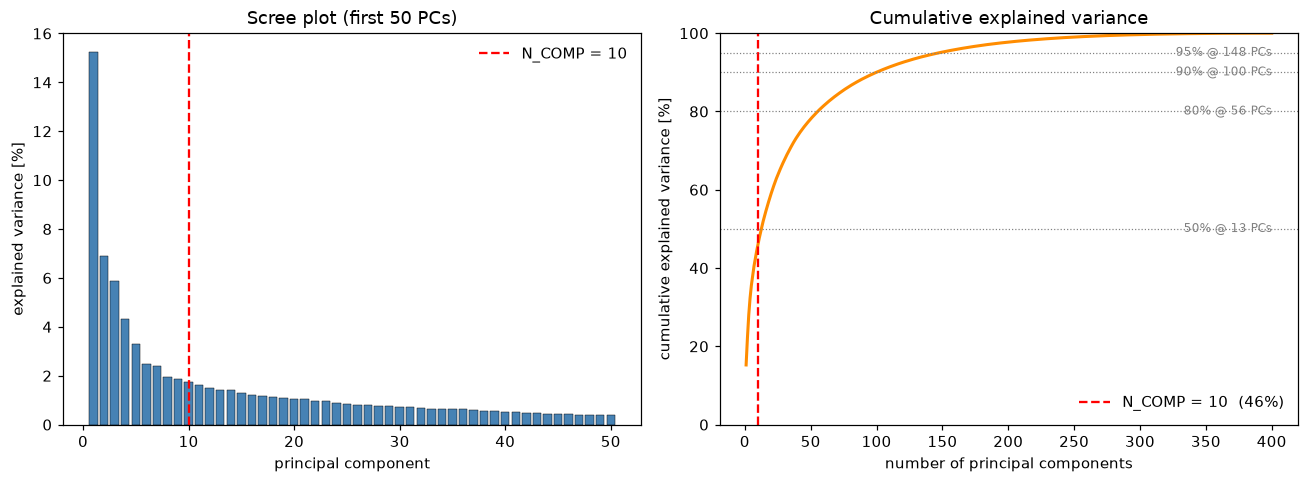

In [4]:
# full PCA spectrum on the standardized k-mer matrix
pca_full = PCA(random_state=0).fit(Xstd)
evr = pca_full.explained_variance_ratio_
cum = np.cumsum(evr)
comps = np.arange(1, len(evr) + 1)

# number of PCs needed to reach common variance thresholds
thresholds = [0.5, 0.8, 0.9, 0.95]
need = {q: int(np.searchsorted(cum, q) + 1) for q in thresholds}
print("PCs needed to explain: " +
      ", ".join(f"{int(q*100)}% -> {n}" for q, n in need.items()))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

# left: scree (per-PC), zoom to first ~50 PCs where the action is
n_show = 50
ax1.bar(comps[:n_show], evr[:n_show] * 100, color="steelblue", edgecolor="black", linewidth=0.3)
ax1.axvline(N_COMP, color="red", ls="--", lw=1.5, label=f"N_COMP = {N_COMP}")
ax1.set_xlabel("principal component")
ax1.set_ylabel("explained variance [%]")
ax1.set_title(f"Scree plot (first {n_show} PCs)")
ax1.legend(frameon=False)

# right: cumulative explained variance, full spectrum
ax2.plot(comps, cum * 100, color="darkorange", lw=2)
ax2.axvline(N_COMP, color="red", ls="--", lw=1.5,
            label=f"N_COMP = {N_COMP}  ({cum[N_COMP-1]:.0%})")
for q in thresholds:
    ax2.axhline(q * 100, color="gray", ls=":", lw=0.8)
    ax2.text(len(evr), q * 100, f" {int(q*100)}% @ {need[q]} PCs",
             va="center", ha="right", fontsize=8, color="gray")
ax2.set_xlabel("number of principal components")
ax2.set_ylabel("cumulative explained variance [%]")
ax2.set_title("Cumulative explained variance")
ax2.set_ylim(0, 100)
ax2.legend(frameon=False, loc="lower right")

plt.tight_layout()
plt.show()

## 3. KSG kNN mutual-information estimator

For continuous $X$ and $Y$ the Kraskov–Stögbauer–Grassberger estimator
(algorithm 1) is

$$\hat I(X;Y) = \psi(k) + \psi(N) - \big\langle \psi(n_x+1) + \psi(n_y+1) \big\rangle$$

where $\psi$ is the digamma function, $N$ the sample size, $k$ the neighbor rank,
and for each point $i$: $\varepsilon_i$ is the distance to its $k$-th nearest
neighbor in the **joint** space under the max (Chebyshev) norm, while $n_x(i)$ /
$n_y(i)$ count the points lying within $\varepsilon_i$ in the $X$ / $Y$ marginal.
We z-score each coordinate (so the max-norm weighs the multivariate $X$ and the
scalar $Y$ comparably) and add infinitesimal noise to break ties.

In [5]:
def ksg_mi(X, Y, k=5, noise=1e-10, seed=0):
    "KSG (Kraskov 2004) algorithm-1 estimate of I(X;Y) in nats. X:(N,dx), Y:(N,dy)/(N,)."
    rng = np.random.default_rng(seed)
    X = np.asarray(X, float); Y = np.asarray(Y, float)
    if X.ndim == 1: X = X[:, None]
    if Y.ndim == 1: Y = Y[:, None]
    N = X.shape[0]
    # z-score marginals so the joint max-norm is balanced, then break ties
    X = (X - X.mean(0)) / (X.std(0) + 1e-12) + noise * rng.standard_normal(X.shape)
    Y = (Y - Y.mean(0)) / (Y.std(0) + 1e-12) + noise * rng.standard_normal(Y.shape)
    XY = np.hstack([X, Y])
    # distance to the k-th neighbour in joint space (self excluded -> index k)
    dist, _ = cKDTree(XY).query(XY, k=k + 1, p=np.inf)
    eps = dist[:, k]
    # marginal counts within eps (return_length includes the point itself = n+1)
    nx1 = cKDTree(X).query_ball_point(X, eps - 1e-12, p=np.inf, return_length=True)
    ny1 = cKDTree(Y).query_ball_point(Y, eps - 1e-12, p=np.inf, return_length=True)
    mi = digamma(k) + digamma(N) - np.mean(digamma(nx1) + digamma(ny1))
    return max(mi, 0.0)

### Validation

For a bivariate Gaussian with correlation $\rho$ the true MI is
$I = -\tfrac12\ln(1-\rho^2)$ nats. The estimator should track this, and agree
with `sklearn.feature_selection.mutual_info_regression` (which uses the same
KSG/Ross kNN method).

In [6]:
print(f"{'rho':>5} {'KSG':>8} {'analytic':>9} {'sklearn':>9}")
for rho in [0.0, 0.3, 0.6, 0.9]:
    s = rng.multivariate_normal([0, 0], [[1, rho], [rho, 1]], 3000)
    true = -0.5 * np.log(1 - rho**2)
    ours = ksg_mi(s[:, 0], s[:, 1], k=5)
    skl = mutual_info_regression(s[:, [0]], s[:, 1], n_neighbors=5, random_state=0)[0]
    print(f"{rho:>5} {ours:>8.3f} {true:>9.3f} {skl:>9.3f}")

  rho      KSG  analytic   sklearn


  0.0    0.000    -0.000     0.000
  0.3    0.043     0.047     0.043
  0.6    0.222     0.223     0.222
  0.9    0.840     0.830     0.840


## 4. MI pipeline across the quantitative traits

For each trait we keep the rows that have both a sequence and a value for that
trait, take the sequence embedding $X = Z$ and the trait vector $y$, and compute
$\hat I(X; y)$. Because KSG is positively biased on finite samples, we also build
a **label-shuffled null**: permute $y$ many times and re-estimate. The gap
between the real MI and the null mean (summarized by a z-score and a permutation
p-value) is the signal that is actually attributable to the sequence.

In [7]:
K_NN = 5
N_PERM = 200
NATS_TO_BITS = 1.0 / np.log(2)

rows = []
for t in TRAITS:
    mask = seq_mask & df[t].notna()
    idx = df.index[mask]
    X = Z_df.loc[idx].to_numpy()
    y = df.loc[idx, t].to_numpy(float)
    mi = ksg_mi(X, y, k=K_NN)
    null = np.array([ksg_mi(X, rng.permutation(y), k=K_NN, seed=p + 1)
                     for p in range(N_PERM)])
    z = (mi - null.mean()) / (null.std() + 1e-12)
    pval = (np.sum(null >= mi) + 1) / (N_PERM + 1)
    rows.append(dict(trait=t, n=len(y),
                     mi_nats=mi, mi_bits=mi * NATS_TO_BITS,
                     null_mean_bits=null.mean() * NATS_TO_BITS,
                     null_std_bits=null.std() * NATS_TO_BITS,
                     z=z, p=pval))

res = pd.DataFrame(rows).sort_values("mi_bits", ascending=False).reset_index(drop=True)
res.round(3)

,trait,n,mi_nats,mi_bits,null_mean_bits,null_std_bits,z,p
0,em_max,901,0.879,1.268,0.008,0.012,102.774,0.005
1,ex_max,941,0.862,1.243,0.009,0.014,90.294,0.005
2,qy,744,0.437,0.631,0.010,0.015,42.536,0.005
3,brightness,647,0.407,0.587,0.011,0.016,35.947,0.005
4,ext_coeff,679,0.303,0.437,0.012,0.017,25.568,0.005
5,pka,447,0.299,0.431,0.012,0.018,23.746,0.005
6,maturation,179,0.110,0.159,0.013,0.022,6.509,0.005


## 5. Visualization — MI per trait

Bars show the estimated $I(\text{sequence};\text{trait})$ in bits; the red hatched
overlay is the shuffled-null mean (the estimator's finite-sample floor), and the
black whisker is ±1 SD of the null. Stars mark the permutation significance
(`***` p<0.01, `**` p<0.05, `*` p<0.10).

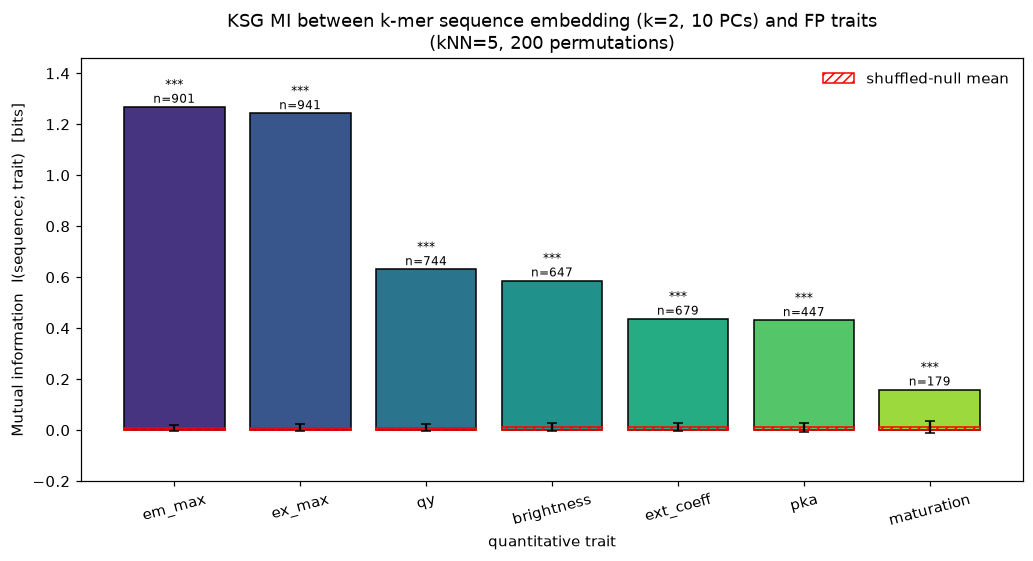

In [8]:
fig, ax = plt.subplots(figsize=(9.5, 5.2))
colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(res)))

bars = ax.bar(res["trait"], res["mi_bits"], color=colors, edgecolor="black", zorder=2)
# null floor + spread
ax.bar(res["trait"], res["null_mean_bits"], color="none", edgecolor="red",
       hatch="////", linewidth=1.0, zorder=3, label="shuffled-null mean")
ax.errorbar(res["trait"], res["null_mean_bits"], yerr=res["null_std_bits"],
            fmt="none", ecolor="black", capsize=3, zorder=4)

def stars(p):
    return "***" if p < 0.01 else "**" if p < 0.05 else "*" if p < 0.10 else "ns"

for b, (_, r) in zip(bars, res.iterrows()):
    ax.text(b.get_x() + b.get_width() / 2, b.get_height(),
            f"{stars(r.p)}\nn={r.n}", ha="center", va="bottom", fontsize=8)

ax.set_ylabel("Mutual information  I(sequence; trait)  [bits]")
ax.set_xlabel("quantitative trait")
ax.set_title(f"KSG MI between k-mer sequence embedding (k={K}, {N_COMP} PCs) "
             f"and FP traits\n(kNN={K_NN}, {N_PERM} permutations)")
ax.margins(y=0.15)
ax.legend(frameon=False)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## 6. Sensitivity to the kNN neighbor count `k`

The KSG estimate depends on the neighbor rank `k`: small `k` gives low bias but
high variance, large `k` smooths the estimate downward. Crucially the
shuffled-null floor also moves with `k`, so the *raw* MI shifting with `k` is
expected and not by itself a problem. What should be stable is the **net** MI —
the estimate minus its own shuffled-null floor at each `k` — and the **ranking**
of traits. Below we sweep `k` and plot both the raw and the null-corrected MI.

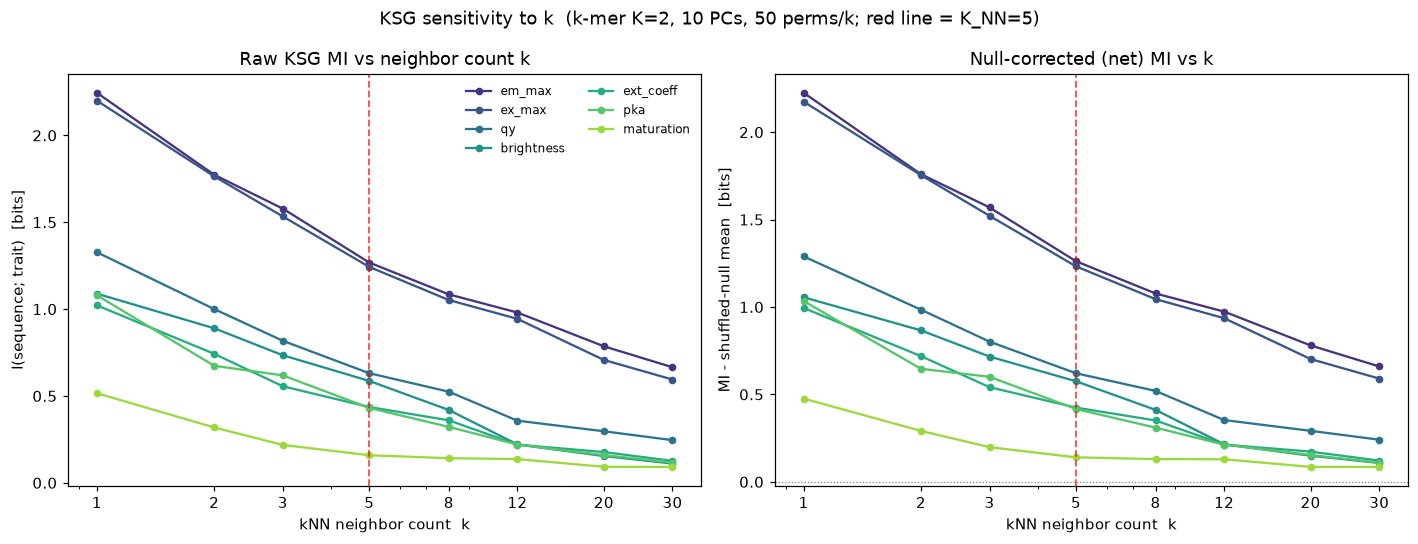

Spearman rank-correlation of net-MI ordering vs k = K_NN:
  k= 1:  rho = +0.964
  k= 2:  rho = +1.000
  k= 3:  rho = +0.964
  k= 5:  rho = +1.000
  k= 8:  rho = +1.000
  k=12:  rho = +1.000
  k=20:  rho = +0.893
  k=30:  rho = +0.893


In [9]:
K_SWEEP = [1, 2, 3, 5, 8, 12, 20, 30]
N_PERM_K = 50

# precompute (X, y) per trait once
trait_data = {}
for t in TRAITS:
    idx = df.index[seq_mask & df[t].notna()]
    trait_data[t] = (Z_df.loc[idx].to_numpy(), df.loc[idx, t].to_numpy(float))

raw = {t: [] for t in TRAITS}      # raw MI (bits) vs k
net = {t: [] for t in TRAITS}      # MI - null mean (bits) vs k
for t in TRAITS:
    X, y = trait_data[t]
    for k in K_SWEEP:
        mi = ksg_mi(X, y, k=k)
        null = np.mean([ksg_mi(X, rng.permutation(y), k=k, seed=p + 1)
                        for p in range(N_PERM_K)])
        raw[t].append(mi * NATS_TO_BITS)
        net[t].append((mi - null) * NATS_TO_BITS)

order = res["trait"].tolist()                       # keep the section-5 ranking/colors
cmap = dict(zip(order, plt.cm.viridis(np.linspace(0.15, 0.85, len(order)))))

fig, (axR, axN) = plt.subplots(1, 2, figsize=(13, 5), sharex=True)
for t in order:
    axR.plot(K_SWEEP, raw[t], "-o", ms=4, color=cmap[t], label=t)
    axN.plot(K_SWEEP, net[t], "-o", ms=4, color=cmap[t], label=t)

axR.set_title("Raw KSG MI vs neighbor count k")
axR.set_ylabel("I(sequence; trait)  [bits]")
axN.set_title("Null-corrected (net) MI vs k")
axN.set_ylabel("MI - shuffled-null mean  [bits]")
axN.axhline(0, color="gray", lw=0.8, ls=":")
for ax in (axR, axN):
    ax.set_xlabel("kNN neighbor count  k")
    ax.set_xscale("log")
    ax.set_xticks(K_SWEEP); ax.set_xticklabels(K_SWEEP)
    ax.axvline(K_NN, color="red", ls="--", lw=1.2, alpha=0.7)
axR.legend(frameon=False, fontsize=8, ncol=2)
fig.suptitle(f"KSG sensitivity to k  (k-mer K={K}, {N_COMP} PCs, {N_PERM_K} perms/k; "
             f"red line = K_NN={K_NN})")
plt.tight_layout()
plt.show()

# is the trait ranking stable across k? (Spearman of net-MI ranking vs the k=K_NN ranking)
from scipy.stats import spearmanr
net_mat = np.array([net[t] for t in order])          # traits x k
ref = net_mat[:, K_SWEEP.index(K_NN)]
print("Spearman rank-correlation of net-MI ordering vs k = K_NN:")
for j, k in enumerate(K_SWEEP):
    rho = spearmanr(net_mat[:, j], ref).statistic
    print(f"  k={k:>2}:  rho = {rho:+.3f}")

### Notes & caveats

- **MI is reported in bits**; the shuffled-null floor reflects the KSG estimator's
  positive finite-sample bias, so the *real* sequence→trait dependence is the
  excess of each bar above its red null line (captured by the z-score / p-value).
- Sample sizes differ sharply across traits (`maturation` n≈179 vs `ex_max`
  n≈940); smaller n means a noisier, higher-variance estimate.
- The sequence is summarized by a length-normalized **k=2** k-mer embedding
  reduced to 10 PCs. Larger k (3-mers), more PCs, or a different embedding
  (e.g. learned protein-language-model features) would capture finer sequence
  structure — `K`, `N_COMP`, `K_NN`, and `N_PERM` are the knobs to explore.

# 7. Same KSG analysis on the spectral data

Instead of the amino-acid sequence, we now use each protein's **excitation +
emission spectrum** as the representation $X$, and ask how much information the
*spectral shape* carries about each quantitative trait.

Construction (parallel to the sequence pipeline):

1. Resample every protein's excitation and emission curve onto a common
   wavelength grid and concatenate them into one fixed-length spectral vector
   (curves are already max-normalized to [0, 1] in FPbase).
2. Reduce to a compact embedding with PCA (spectra are smooth and highly
   redundant, so few PCs capture most of the variance).
3. Run the identical KSG + shuffled-null pipeline over the traits.

Note the built-in sanity check: `ex_max` / `em_max` are essentially the peak
positions of these very curves, so their MI with the spectrum should be near the
top — a near-deterministic relationship the estimator ought to recover.

In [10]:
# --- build a fixed-length spectral vector per protein (slug) ---
spec = pd.read_csv("fpbase_output/fpbase_spectra_long.csv")
GRID = np.arange(350, 751, 2)        # common wavelength grid: 350-750 nm @ 2 nm (201 pts)

def resample_by_slug(sub):
    "slug -> intensity resampled onto GRID, averaging over any multiple states."
    out = {}
    for slug, g in sub.groupby("slug"):
        gg = g.groupby("wavelength")["intensity"].mean()
        out[slug] = np.interp(GRID, gg.index.to_numpy(), gg.to_numpy(), left=0.0, right=0.0)
    return out

ex_map = resample_by_slug(spec[spec.spectrum_type == "excitation"])
em_map = resample_by_slug(spec[spec.spectrum_type == "emission"])

slugs = sorted(set(ex_map) & set(em_map))             # proteins with both curves
S = np.vstack([np.concatenate([ex_map[s], em_map[s]]) for s in slugs])  # (n_prot, 2*len(GRID))
S_df = pd.DataFrame(S, index=pd.Index(slugs, name="slug"))

# slug-level trait values (mean across that protein's states)
traits_by_slug = df.groupby("slug")[TRAITS].mean()

print(f"spectral matrix S: {S.shape}  "
      f"({len(GRID)} excitation + {len(GRID)} emission features over {GRID[0]}-{GRID[-1]} nm)")
print(f"proteins with both ex+em spectra: {len(slugs)}")

spectral matrix S: (450, 402)  (201 excitation + 201 emission features over 350-750 nm)
proteins with both ex+em spectra: 450


spectral embedding Zs: (450, 10)
cumulative variance explained by 10 PCs: 88.0%


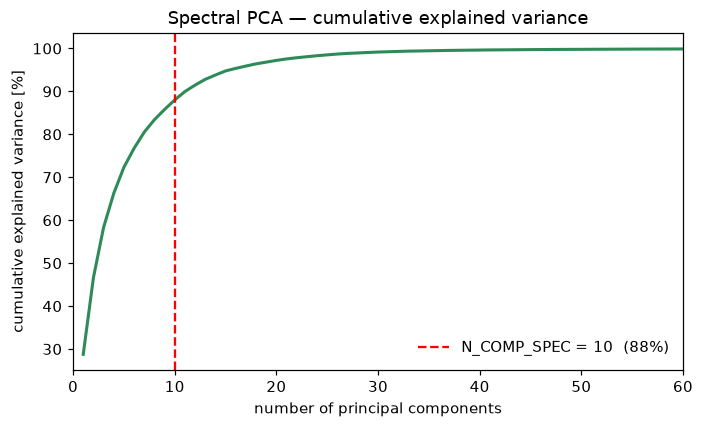

In [11]:
# --- PCA embedding of the spectra ---
N_COMP_SPEC = 10
S_std = StandardScaler().fit_transform(S)
pca_spec = PCA(n_components=N_COMP_SPEC, random_state=0).fit(S_std)
Zs = pca_spec.transform(S_std)
Zs_df = pd.DataFrame(Zs, index=S_df.index)

pca_spec_full = PCA(random_state=0).fit(S_std)
cum_s = np.cumsum(pca_spec_full.explained_variance_ratio_)
print(f"spectral embedding Zs: {Zs.shape}")
print(f"cumulative variance explained by {N_COMP_SPEC} PCs: {cum_s[N_COMP_SPEC-1]:.1%}")

fig, ax = plt.subplots(figsize=(6.5, 4))
ax.plot(np.arange(1, len(cum_s) + 1), cum_s * 100, color="seagreen", lw=2)
ax.axvline(N_COMP_SPEC, color="red", ls="--", lw=1.5,
           label=f"N_COMP_SPEC = {N_COMP_SPEC}  ({cum_s[N_COMP_SPEC-1]:.0%})")
ax.set_xlim(0, 60)
ax.set_xlabel("number of principal components")
ax.set_ylabel("cumulative explained variance [%]")
ax.set_title("Spectral PCA — cumulative explained variance")
ax.legend(frameon=False, loc="lower right")
plt.tight_layout()
plt.show()

In [12]:
# --- reusable MI pipeline (same KSG + shuffled-null as section 4) ---
def mi_pipeline(emb_df, trait_frame, traits=TRAITS, k=K_NN, n_perm=N_PERM, min_n=30):
    out = []
    for t in traits:
        idx = emb_df.index.intersection(trait_frame.index[trait_frame[t].notna()])
        if len(idx) < min_n:
            continue
        X = emb_df.loc[idx].to_numpy()
        y = trait_frame.loc[idx, t].to_numpy(float)
        mi = ksg_mi(X, y, k=k)
        null = np.array([ksg_mi(X, rng.permutation(y), k=k, seed=p + 1) for p in range(n_perm)])
        out.append(dict(trait=t, n=len(y),
                        mi_bits=mi * NATS_TO_BITS,
                        null_mean_bits=null.mean() * NATS_TO_BITS,
                        null_std_bits=null.std() * NATS_TO_BITS,
                        z=(mi - null.mean()) / (null.std() + 1e-12),
                        p=(np.sum(null >= mi) + 1) / (n_perm + 1)))
    return pd.DataFrame(out).sort_values("mi_bits", ascending=False).reset_index(drop=True)

res_spec = mi_pipeline(Zs_df, traits_by_slug)
res_spec.round(3)

,trait,n,mi_bits,null_mean_bits,null_std_bits,z,p
0,ex_max,450,2.028,0.013,0.018,110.483,0.005
1,em_max,450,1.909,0.013,0.018,106.314,0.005
2,qy,424,0.676,0.013,0.020,33.981,0.005
3,ext_coeff,351,0.643,0.012,0.018,35.113,0.005
4,brightness,348,0.637,0.013,0.020,31.744,0.005
5,pka,306,0.399,0.014,0.020,19.365,0.005
6,maturation,124,0.213,0.016,0.027,7.329,0.005


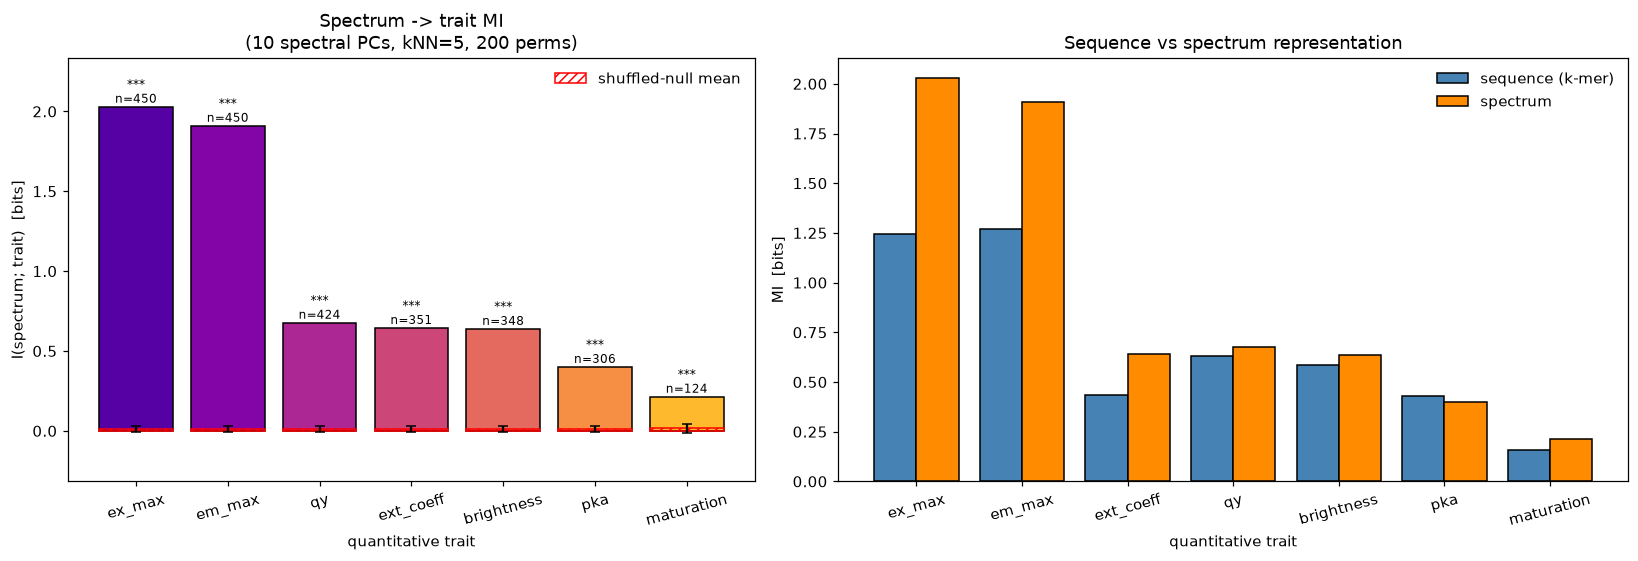

In [13]:
# --- bar plot: spectrum MI per trait, plus side-by-side with the sequence MI ---
def stars(p):
    return "***" if p < 0.01 else "**" if p < 0.05 else "*" if p < 0.10 else "ns"

fig, (axA, axB) = plt.subplots(1, 2, figsize=(15, 5.2),
                               gridspec_kw={"width_ratios": [1, 1.15]})

# (A) spectrum MI, same style as section 5
colors = plt.cm.plasma(np.linspace(0.15, 0.85, len(res_spec)))
bars = axA.bar(res_spec["trait"], res_spec["mi_bits"], color=colors, edgecolor="black", zorder=2)
axA.bar(res_spec["trait"], res_spec["null_mean_bits"], color="none", edgecolor="red",
        hatch="////", linewidth=1.0, zorder=3, label="shuffled-null mean")
axA.errorbar(res_spec["trait"], res_spec["null_mean_bits"], yerr=res_spec["null_std_bits"],
             fmt="none", ecolor="black", capsize=3, zorder=4)
for b, (_, r) in zip(bars, res_spec.iterrows()):
    axA.text(b.get_x() + b.get_width() / 2, b.get_height(),
             f"{stars(r.p)}\nn={r.n}", ha="center", va="bottom", fontsize=8)
axA.set_ylabel("I(spectrum; trait)  [bits]")
axA.set_xlabel("quantitative trait")
axA.set_title(f"Spectrum -> trait MI\n({N_COMP_SPEC} spectral PCs, kNN={K_NN}, {N_PERM} perms)")
axA.margins(y=0.15)
axA.legend(frameon=False)
axA.tick_params(axis="x", rotation=15)

# (B) sequence vs spectrum, grouped by trait
seq_mi = res.set_index("trait")["mi_bits"]
spec_mi = res_spec.set_index("trait")["mi_bits"]
order = TRAITS
x = np.arange(len(order)); w = 0.4
axB.bar(x - w/2, [seq_mi.get(t, np.nan) for t in order], w,
        label="sequence (k-mer)", color="steelblue", edgecolor="black")
axB.bar(x + w/2, [spec_mi.get(t, np.nan) for t in order], w,
        label="spectrum", color="darkorange", edgecolor="black")
axB.set_xticks(x); axB.set_xticklabels(order, rotation=15)
axB.set_ylabel("MI  [bits]")
axB.set_xlabel("quantitative trait")
axB.set_title("Sequence vs spectrum representation")
axB.legend(frameon=False)

plt.tight_layout()
plt.show()

# 8. Mutual information between sequence and spectrum

Here both variables are *representations*: we estimate $I(\text{sequence};
\text{spectrum})$ — how much the amino-acid sequence tells us about the optical
spectrum (and vice versa). KSG handles a multivariate $Y$ exactly as a
multivariate $X$, so we simply feed the PCA-embedded spectrum as $Y$ instead of a
scalar trait. We compute three quantities on the proteins that have both a
sequence and the relevant curve:

- $I(\text{sequence};\ \text{full spectrum})$  (excitation **+** emission)
- $I(\text{sequence};\ \text{excitation spectrum})$
- $I(\text{sequence};\ \text{emission spectrum})$

Each spectrum block gets its own PCA embedding; the null is built by permuting
the protein↔spectrum pairing (shuffling the rows of $Y$).

In [14]:
# --- slug-level sequence embedding (one sequence per protein -> reuse Z) ---
slug_of_row = df.loc[Z_df.index, "slug"]
seqZ_slug = Z_df.groupby(slug_of_row.values).mean()       # identical rows per slug -> mean = the embedding
seqZ_slug.index.name = "slug"

# --- separate PCA embeddings for the excitation-only and emission-only spectra ---
def pca_embed(intensity_map, n_comp=N_COMP_SPEC):
    keys = sorted(intensity_map)
    M = np.vstack([intensity_map[s] for s in keys])
    Z = PCA(n_components=n_comp, random_state=0).fit_transform(StandardScaler().fit_transform(M))
    return pd.DataFrame(Z, index=pd.Index(keys, name="slug"))

exZ_df = pca_embed(ex_map)     # excitation spectrum embedding
emZ_df = pca_embed(em_map)     # emission spectrum embedding
# Zs_df (built in section 7) is the full ex+em spectrum embedding

print(f"sequence embedding (per slug): {seqZ_slug.shape}")
print(f"excitation embedding: {exZ_df.shape},  emission embedding: {emZ_df.shape},  "
      f"full-spectrum embedding: {Zs_df.shape}")

sequence embedding (per slug): (990, 10)
excitation embedding: (452, 10),  emission embedding: (451, 10),  full-spectrum embedding: (450, 10)


In [15]:
# --- MI between two (multivariate) embeddings, with a paired-shuffle null ---
def mi_between(Xdf, Ydf, label, k=K_NN, n_perm=N_PERM):
    idx = Xdf.index.intersection(Ydf.index)
    X = Xdf.loc[idx].to_numpy()
    Y = Ydf.loc[idx].to_numpy()
    mi = ksg_mi(X, Y, k=k)
    null = np.array([ksg_mi(X, Y[rng.permutation(len(idx))], k=k, seed=p + 1)
                     for p in range(n_perm)])
    return dict(pair=label, n=len(idx),
                mi_bits=mi * NATS_TO_BITS,
                null_mean_bits=null.mean() * NATS_TO_BITS,
                null_std_bits=null.std() * NATS_TO_BITS,
                z=(mi - null.mean()) / (null.std() + 1e-12),
                p=(np.sum(null >= mi) + 1) / (n_perm + 1))

res_seqspec = pd.DataFrame([
    mi_between(seqZ_slug, Zs_df,  "sequence ↔ full spectrum"),
    mi_between(seqZ_slug, exZ_df, "sequence ↔ excitation"),
    mi_between(seqZ_slug, emZ_df, "sequence ↔ emission"),
])
res_seqspec.round(3)

,pair,n,mi_bits,null_mean_bits,null_std_bits,z,p
0,sequence ↔ full spectrum,432,1.616,0.015,0.024,67.112,0.005
1,sequence ↔ excitation,433,1.427,0.015,0.022,65.555,0.005
2,sequence ↔ emission,432,1.748,0.014,0.020,85.504,0.005


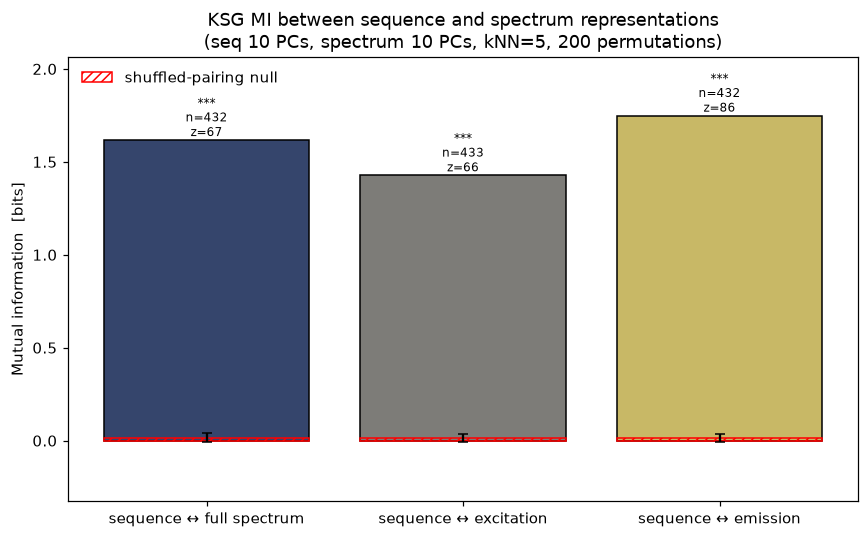

In [16]:
# --- bar plot: I(sequence; spectrum) for the three spectrum types ---
fig, ax = plt.subplots(figsize=(8, 5))
colors = plt.cm.cividis(np.linspace(0.2, 0.8, len(res_seqspec)))

bars = ax.bar(res_seqspec["pair"], res_seqspec["mi_bits"], color=colors, edgecolor="black", zorder=2)
ax.bar(res_seqspec["pair"], res_seqspec["null_mean_bits"], color="none", edgecolor="red",
       hatch="////", linewidth=1.0, zorder=3, label="shuffled-pairing null")
ax.errorbar(res_seqspec["pair"], res_seqspec["null_mean_bits"], yerr=res_seqspec["null_std_bits"],
            fmt="none", ecolor="black", capsize=3, zorder=4)

for b, (_, r) in zip(bars, res_seqspec.iterrows()):
    ax.text(b.get_x() + b.get_width() / 2, b.get_height(),
            f"{stars(r.p)}\nn={r.n}\nz={r.z:.0f}", ha="center", va="bottom", fontsize=8)

ax.set_ylabel("Mutual information  [bits]")
ax.set_title(f"KSG MI between sequence and spectrum representations\n"
             f"(seq {N_COMP} PCs, spectrum {N_COMP_SPEC} PCs, kNN={K_NN}, {N_PERM} permutations)")
ax.margins(y=0.18)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()